In [10]:
#Il primo passo è caricare il dataset e pre-elaborare i dati.
import pandas as pd
df = pd.read_csv("spettacolli.csv")
print(df)

    Age  Experience  Rank Nationality   Go
0    36          10     9          UK  YES
1    42          12     4         USA   NO
2    28           5     6           N  YES
3    55          20     8          UK  YES
4    30           7     5         USA   NO
5    48          15     7          UK  YES
6    22           3     3           N   NO
7    60          25     9         USA  YES
8    35           8     6          UK   NO
9    40          11     7         USA  YES
10   29           6     5           N  YES
11   50          18     8          UK  YES
12   25           4     4         USA   NO


In [11]:
#Gli alberi decisionali, come la maggior parte degli algoritmi 
#di ML, lavorano meglio con dati numerici. Le colonne 
#'Nationality' (Nazionalità) e 'Go' (Presenza) sono categoriche 
#e vengono mappate a valori numerici.
d = {'UK': 0, 'USA': 1, 'N': 2}
df['Nationality'] = df['Nationality'].map(d)
d = {'YES': 1, 'NO': 0}
df['Go'] = df['Go'].map(d)
print(df)

    Age  Experience  Rank  Nationality  Go
0    36          10     9            0   1
1    42          12     4            1   0
2    28           5     6            2   1
3    55          20     8            0   1
4    30           7     5            1   0
5    48          15     7            0   1
6    22           3     3            2   0
7    60          25     9            1   1
8    35           8     6            0   0
9    40          11     7            1   1
10   29           6     5            2   1
11   50          18     8            0   1
12   25           4     4            1   0


In [13]:
#Si definiscono le colonne delle caratteristiche (features) 
#che verranno utilizzate per fare previsioni e la colonna 
#target (y) che è il valore che si vuole prevedere.
features = ['Age', 'Experience', 'Rank', 'Nationality']
X = df[features]
y = df['Go']
print('colonne della features: ',X)
print("-" * 40)
print('colonne del target: ',y)

colonne della features:      Age  Experience  Rank  Nationality
0    36          10     9            0
1    42          12     4            1
2    28           5     6            2
3    55          20     8            0
4    30           7     5            1
5    48          15     7            0
6    22           3     3            2
7    60          25     9            1
8    35           8     6            0
9    40          11     7            1
10   29           6     5            2
11   50          18     8            0
12   25           4     4            1
----------------------------------------
colonne del target:  0     1
1     0
2     1
3     1
4     0
5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
Name: Go, dtype: int64


In [14]:
#Si importano le classi necessarie da sklearn.tree e si 
#inizializza un DecisionTreeClassifier. Il modello viene poi 
#addestrato sui dati X (features) e y (target).
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

dtree = DecisionTreeClassifier()
dtree = dtree.fit(X, y)

[Text(0.6, 0.875, 'Rank <= 6.5\ngini = 0.473\nsamples = 13\nvalue = [5, 8]'),
 Text(0.4, 0.625, 'Nationality <= 1.5\ngini = 0.408\nsamples = 7\nvalue = [5, 2]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.6, 0.375, 'Rank <= 4.0\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.7, 0.75, '  False')]

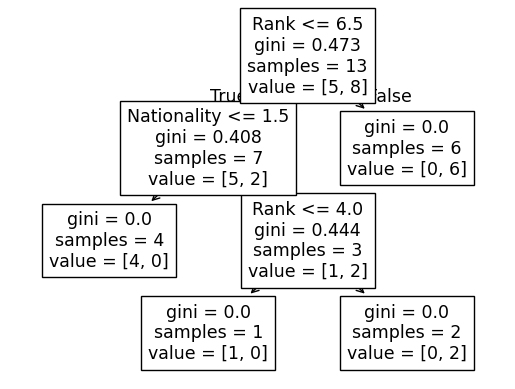

In [15]:
#tree.plot_tree() viene usato per visualizzare l'albero 
#decisionale addestrato, rendendo evidente il percorso delle 
#decisioni.
tree.plot_tree(dtree, feature_names=features)

In [25]:
#Una volta addestrato, l'albero può essere usato per prevedere 
#nuovi valori utilizzando il metodo predict().
#Esempio: Prevedere per un comico americano di 40 anni, con 10 
#anni di esperienza e un rank pari a 7.
print(dtree.predict([[40, 10, 7, 1]])) # Output: [1] (YES)
print(dtree.predict([[26, 4, 5, 0]]))
print(dtree.predict([[40, 12, 7, 0]])) # Output: [0] (NO)

[1]
[0]
[1]


C:\Users\Roman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Roman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Roman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


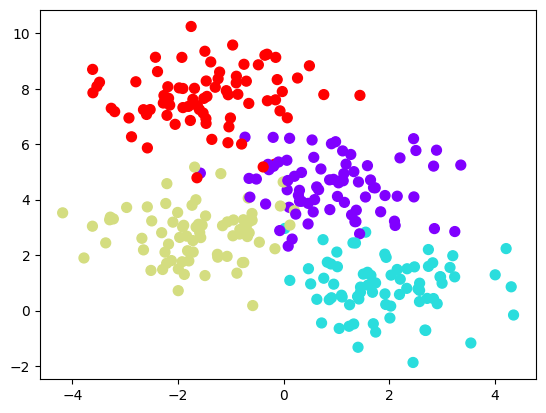

In [28]:
#Consideriamo i seguenti dati bidimensionali, 
#che hanno una delle quattro etichette di classe:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=4,
                  random_state=0, cluster_std=1.0)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='rainbow')

In [29]:
#Questo processo di adattamento di un albero decisionale ai 
#nostri dati, come già visto, può essere eseguito in Scikit-Learn 
#con lo stimatore DecisionTreeClassifier:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier().fit(X, y)

In [31]:
#Scriviamo ora una rapida funzione di utilità che ci aiuti a 
#visualizzare l'output del classificatore:
import numpy as np


def visualize_classifier(model, X, y, ax=None, cmap='rainbow'):
    ax = ax or plt.gca()

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=cmap,
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # fit the estimator
    model.fit(X, y)
    xx, yy = np.meshgrid(np.linspace(*xlim, num=200),
                         np.linspace(*ylim, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Create a color plot with the results
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap=cmap, zorder=1)

    ax.set(xlim=xlim, ylim=ylim)

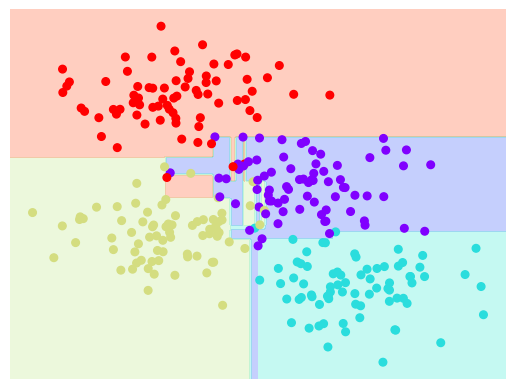

In [32]:
#Ora possiamo esaminare come appare la classificazione 
#dell'albero decisionale:
visualize_classifier(DecisionTreeClassifier(), X, y)